### Домашняя работа

**Задание простого уровня** Загрузите данные из файла `non_linear.csv` и сгенерируйте данные до степени *degree = 8* включительно. Обучите модель `sklearn.linear_model.Lasso` и модель `sklearn.linear_model.Ridge` на полученных данных, используйте коэффициент регуляризации $\alpha=0.8$ для обеих моделей. Постройте два столбчатых графика, на которых отобразите величину коэффициентов для Ridge регрессии и Lasso регрессии в виде столбиков.

Пример графиков для 3-й степени (просто для примера, у вас может по-другому выглядеть). Какой можно сделать в вывод по величине коэффициентов?:
![coeff_example](https://pp.userapi.com/c850136/v850136613/19282c/OfwruuxOkPw.jpg)

# Новый раздел

# Новый раздел

In [2]:
# -- ВАШ КОД ТУТ
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

data = pd.read_csv('../3/3.10_non_linear.csv', sep=',')
data.head()

,x_train,y_train
0,0.138368,0.838812
1,0.157237,0.889313
2,0.188684,1.430040
3,0.685553,1.717309
4,0.874237,2.032588


Пока что мы пользуемся моделями с регуляризацией как "черным ящиком" - знаем, как применять и это работает! Для успешного решения задач этого достаточно. Если вам, как и мне, интересно *почему* это работает - добро пожаловать во второй урок, где Вас ждёт больше кода и формул!

In [1]:
def generate_degrees(source_data: list, degree: int):
    """Функция, которая принимает на вход одномерный массив, а возвращает n-мерный
    Для каждой степени от 1 до  degree возводим x в эту степень
    """
    return np.array([
          source_data**n for n in range(1, degree + 1)
    ]).T

C:\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.365e-01, tolerance: 2.448e-03
  model = cd_fast.enet_coordinate_descent(
C:\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.198e-01, tolerance: 2.448e-03
  model = cd_fast.enet_coordinate_descent(
C:\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.359e+00, tolerance: 2.448e-03
  model = cd_fast.enet_

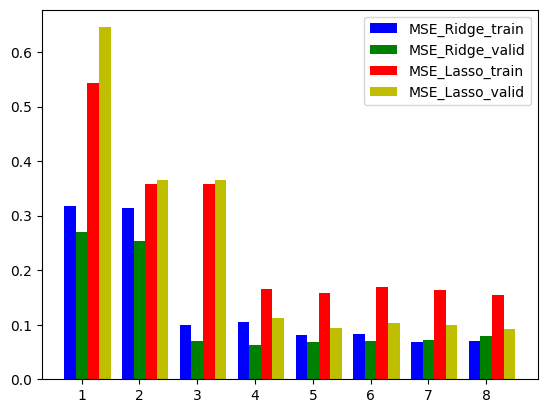

[0.2691918  0.2526163  0.07051586 0.06353172 0.06757627 0.07055461
 0.07128983 0.07852416]
[0.31775725 0.31414958 0.10027094 0.10562556 0.081604   0.08357012
 0.06817542 0.07021038]
[0.64521718 0.36471915 0.36471915 0.11181014 0.09387726 0.10238036
 0.09884981 0.09284713]
[0.54223511 0.35830066 0.35830066 0.16475111 0.15773098 0.16880441
 0.16407832 0.15517204]
['1' '2' '3' '4' '5' '6' '7' '8']


In [15]:
degree = 8
x = np.asarray([1, 2, 3, 4, 5 , 6, 7, 8])
MSE_Ridge_train = np.array([])
MSE_Ridge_valid = np.array([])
MSE_Lasso_train = np.array([])
MSE_Lasso_valid = np.array([])
index = np.arange(degree)
w = 0.2
names = np.array([])
for i in range(1, degree + 1):
    names = np.append(names, str(i))
    X = generate_degrees(data['x_train'], i)
    y = data.y_train.values
    X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=10)
    modelRidge = Ridge(alpha=0.8).fit(X_train, y_train)
    y_pred = modelRidge.predict(X_valid)
    y_pred_train = modelRidge.predict(X_train)
    MSE_Ridge_valid = np.append(MSE_Ridge_valid, mean_squared_error(y_valid, y_pred))
    MSE_Ridge_train = np.append(MSE_Ridge_train, mean_squared_error(y_train, y_pred_train))
    
    modelLasso = Lasso(alpha=0.8).fit(X_train, y_train)
    y_pred = modelLasso.predict(X_valid)
    y_pred_train = modelLasso.predict(X_train)
    MSE_Lasso_valid = np.append(MSE_Lasso_valid, mean_squared_error(y_valid, y_pred))
    MSE_Lasso_train = np.append(MSE_Lasso_train, mean_squared_error(y_train, y_pred_train))
    
plt.bar(x-w, MSE_Ridge_train, w, color='b', label="MSE_Ridge_train")
plt.bar(x, MSE_Ridge_valid, w, color='g', label="MSE_Ridge_valid")
plt.bar(x + w, MSE_Lasso_train, w, color='r', label="MSE_Lasso_train")
plt.bar(x + 2*w, MSE_Lasso_valid, w, color='y', label="MSE_Lasso_valid")
plt.legend()
plt.show()

print(MSE_Ridge_valid)
print(MSE_Ridge_train)
print(MSE_Lasso_valid)
print(MSE_Lasso_train)
print(names)